# Iris Flower Classification

## Réalisé par : Sara Marrakchi

### Objectif

L'objectif de ce projet est de développer un modèle de Machine Learning capable de classifier automatiquement une fleur d'iris en l'une des trois espèces suivantes :

- Setosa
- Versicolor
- Virginica

à partir des mesures de ses sépales et de ses pétales.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv("iris.csv")

In [ ]:
df.head()
df.shape
df.info()
df.isnull().sum()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


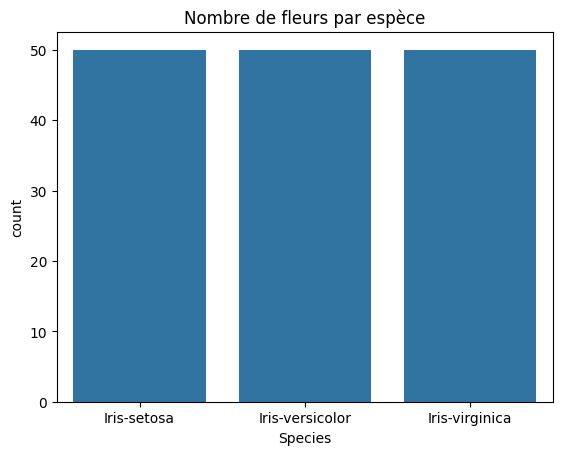

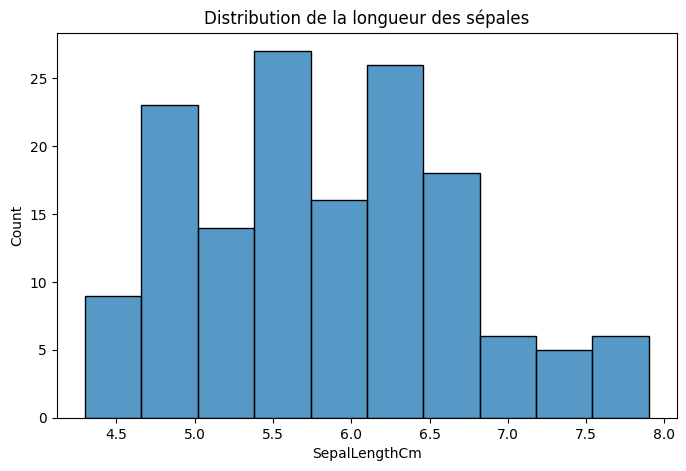

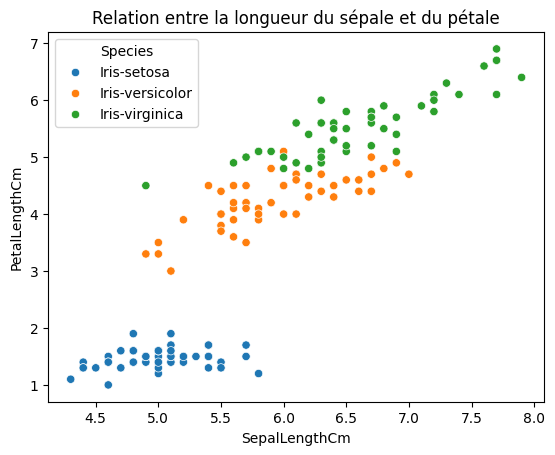

In [ ]:
import seaborn as sns
df["Species"].value_counts()
sns.countplot(data=df, x="Species")
plt.title("Nombre de fleurs par espèce")
plt.show()
plt.figure(figsize=(8,5))

sns.histplot(df["SepalLengthCm"], bins=10)

plt.title("Distribution de la longueur des sépales")

plt.show()

sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="PetalLengthCm",
    hue="Species"
)

plt.title("Relation entre la longueur du sépale et du pétale")

plt.show()

In [ ]:
X = df.drop(["Id", "Species"], axis=1)

y = df["Species"]
X.head()
y.head()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


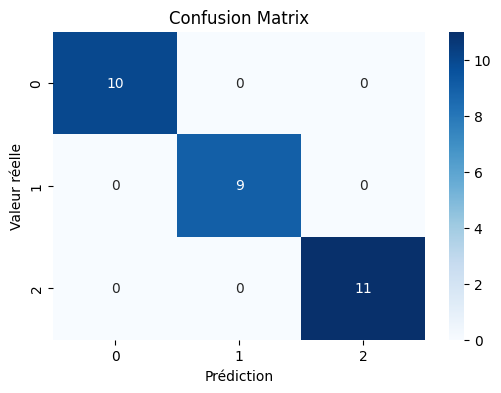

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:

nouvelle_fleur = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
)

prediction = model.predict(nouvelle_fleur)

print("Espèce prédite :", prediction[0])

Espèce prédite : Iris-setosa


# Conclusion

Dans ce projet, nous avons développé un modèle de Machine Learning permettant de classifier les fleurs Iris en trois espèces :
- Iris-setosa
- Iris-versicolor
- Iris-virginica

Les données ont été explorées, nettoyées et visualisées avant l'entraînement du modèle.

Un Decision Tree Classifier a été utilisé et a obtenu une précision de 100 % sur le jeu de test.

Ce projet montre comment appliquer les étapes principales d'un projet de Machine Learning :
- Chargement des données
- Analyse exploratoire
- Prétraitement
- Entraînement du modèle
- Évaluation des performances
- Prédiction de nouvelles observations